<a href="https://colab.research.google.com/github/AdityaBimoP/research-coastal/blob/main/Thesis_CVI_RSCV_Beeswarm_Waterfall_Statistical_Test11_11_6_CVI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Initialization

In [ ]:
# --- 1. SETUP: Install necessary libraries and mount Google Drive ---
print("STEP 1: Installing the 'scikit-posthocs' library...")
!pip install scikit-posthocs -q
!pip install --upgrade pygam -q
!pip install patsy
!pip install pygam

# Now we can safely import all required packages
print("\nSTEP 2: Importing all Python libraries...")
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import sklearn
import glob
import itertools
import math
import random
from tqdm.auto import tqdm
from google.colab import drive
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, log_loss
from sklearn.utils import resample
from scipy.stats import  studentized_range, chi2, friedmanchisquare, rankdata
from scipy.stats import f as f_dist
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scikit_posthocs
import shap
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
import patsy
from patsy import dmatrix, bs, cr, build_design_matrices, dmatrices
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.stats import entropy, spearmanr, kendalltau
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedShuffleSplit
import pygam
from pygam import LogisticGAM, s, l, f as fcat
from statsmodels.gam.api import GLMGam, BSplines
import warnings
import statsmodels.formula.api as smf
from itertools import product, combinations
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
from scipy.special import logsumexp
from patsy.highlevel import ModelDesc
from sklearn.preprocessing import OneHotEncoder
from itertools import combinations
from statsmodels.stats.inter_rater import fleiss_kappa
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.discrete.discrete_model import MNLogit
from scipy.spatial.distance import pdist, squareform
from tqdm import trange
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.anova import anova_lm
from scipy.stats import spearmanr, chi2, t
import os, json, math, warnings
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

print(f"\nPandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Joblib version: {joblib.__version__}")
print(f"JSON version: {json.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Statsmodel version: {sm.__version__}")
print(f"PyGAM version: {pygam.__version__}")
print(f"Patsy version: {patsy.__version__}")
print(f"Scikit Posthocs version: {scikit_posthocs.__version__}")
print(f"SHAP version: {shap.__version__}")

STEP 1: Installing the 'scikit-posthocs' library...

STEP 2: Importing all Python libraries...

Pandas version: 2.2.2
Numpy version: 2.0.2
Seaborn version: 0.13.2
Joblib version: 1.5.2
JSON version: 2.0.9
Scikit-learn version: 1.6.1
Statsmodel version: 0.14.5
PyGAM version: 0.10.1
Patsy version: 1.0.1
Scikit Posthocs version: 0.11.4
SHAP version: 0.48.0


## Drive and Folder Configuration

In [ ]:
# Mount Google Drive to access your project files
print("\nSTEP 3: Mounting Google Drive...")
drive.mount('/content/drive')


# CONFIGURATION: Define all paths to your files ---
print("\nSTEP 4: Configuring file paths...")

# Base directory for your project in Google Drive
BASE_DIR = '/content/drive/MyDrive/CCL_Bantul'

# Paths to the pre-trained models
MODELS_TO_COMPARE = {
    'Random Forest': os.path.join(BASE_DIR, 'results', 'random_forest', 'random_forest_tuned_ml_cvi_model.joblib'),
    'XGBoost': os.path.join(BASE_DIR, 'results', 'xgboost', 'xgboost_tuned_ml_cvi_model.joblib'),
    'LightGBM': os.path.join(BASE_DIR, 'results', 'lightgbm', 'lightgbm_tuned_ml_cvi_model.joblib')
}

# Paths to the separate RAW training/testing datasets and the FITTED IMPUTER
TRAIN_DATA_PATH = os.path.join(BASE_DIR, 'data', 'processed', 'ml_train_data.csv')
TEST_DATA_PATH = os.path.join(BASE_DIR, 'data', 'processed', 'ml_test_data.csv')
IMPUTER_PATH = os.path.join(BASE_DIR, 'results', 'imputer.pkl')


# Path to a metadata file to get the feature list
METADATA_PATH = os.path.join(BASE_DIR, 'results', 'random_forest', 'random_forest_tuned_model_metadata.json')

# Directory for saving new statistical results
STAT_RESULTS_DIR = os.path.join(BASE_DIR, 'results', 'statistical_validation')
os.makedirs(STAT_RESULTS_DIR, exist_ok=True)
print(f"All validation results will be saved in: {STAT_RESULTS_DIR}")

class ModelWrapper:
    def __init__(self, model):
        self.model = model

    def predict_proba(self, X):
        # This method guarantees that we always return class probabilities,
        # which is a stable input for SHAP's interventional explainer.
        return self.model.predict_proba(X)


STEP 3: Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

STEP 4: Configuring file paths...
All validation results will be saved in: /content/drive/MyDrive/CCL_Bantul/results/statistical_validation


### Add Continuous CVI Score Dataset

In [ ]:
def _make_fp_series(df, cols):
    """Stable row fingerprint built from a subset of columns.
    Floats rounded to 6 decimals; categoricals as strings; hashed to int64."""
    use = [c for c in cols if c in df.columns]
    if not use:
        raise ValueError("No overlapping feature columns found to build fingerprints.")
    blocks = []
    for c in use:
        s = df[c]
        if np.issubdtype(s.dtype, np.number):
            blocks.append(s.astype(float).round(6).astype(str))
        else:
            blocks.append(s.astype(str))
    key_df = pd.DataFrame(blocks).T
    return pd.util.hash_pandas_object(key_df, index=False).astype("int64")

def _align_to_train_rows(y_all_series, df_all_for_ml, train_df_raw, features_for_ml):
    """Map master y_all (length N_all) to the exact order of train_df_raw using
    fingerprint + cumcount to handle duplicates."""
    fp_all = _make_fp_series(df_all_for_ml, features_for_ml)
    fp_trn = _make_fp_series(train_df_raw, features_for_ml)

    cc_all = fp_all.groupby(fp_all).cumcount()
    cc_trn = fp_trn.groupby(fp_trn).cumcount()

    map_all = pd.DataFrame({"fp": fp_all, "cc": cc_all, "row_all": np.arange(len(df_all_for_ml))})
    map_trn = pd.DataFrame({"fp": fp_trn, "cc": cc_trn, "row_trn": np.arange(len(train_df_raw))})

    joined = map_trn.merge(map_all, on=["fp","cc"], how="left")
    missing = joined["row_all"].isna().sum()
    if missing:
        print(f"[WARN] Could not align {missing} training rows by fingerprint. "
              f"Check that 'ml_training_input_final.csv' matches your features. "
              f"Falling back: will drop unmatched rows.")
        joined = joined.dropna(subset=["row_all"])
    idx_all = joined["row_all"].astype(int).values
    y_trn = y_all_series.iloc[idx_all].reset_index(drop=True)

    # If we dropped some rows, also shrink train_df_raw to the matched subset (preserve order)
    if len(y_trn) != len(train_df_raw):
        print(f"[INFO] Aligning train_df_raw to {len(y_trn)} matched rows for fair comparison.")
        keep_rows = joined["row_trn"].astype(int).values
        return y_trn, train_df_raw.iloc[keep_rows].reset_index(drop=True)
    return y_trn, train_df_raw.reset_index(drop=True)

def load_cvi_continuous_for_stats(
    BASE_DIR,
    train_df_raw,
    features_for_ml,
    prefer_weights=("equal","entropy"),
    prefer_norm_col="cvi_score_norm",
    recompute_if_missing=True
):
    """
    Load the continuous CVI score that the MAIN file saved, align it to the
    training rows of this statistics session, and return y_score_train (0-1).

    Priority:
      1) {BASE_DIR}/data/processed/traditional_cvi_scores_{weights}.csv
         expects columns ['cvi_score_raw','cvi_score_norm', ...]
      2) Recompute from {BASE_DIR}/data/processed/traditional_cvi_ranked_input.csv
         using geometric mean across ranked columns, normalized to 0-1.

    Alignment:
      Uses ml_training_input_final.csv as the 'master' table to align rows
      (fingerprint join on features_for_ml).
    """
    # (i) load y_all from the exporter CSV if present
    scores_csv = None
    for w in prefer_weights:
        cand = os.path.join(BASE_DIR, "data", "processed", f"traditional_cvi_scores_{w}.csv")
        if os.path.exists(cand):
            scores_csv = cand
            break
    if scores_csv is not None:
        df_scores = pd.read_csv(scores_csv)
        if prefer_norm_col in df_scores.columns:
            y_all = pd.Series(df_scores[prefer_norm_col].astype(float), name="cvi_score_norm")
            print(f"[OK] Loaded CVI continuous scores from: {scores_csv}  (len={len(y_all)})")
        elif "cvi_score_raw" in df_scores.columns:
            y_raw = df_scores["cvi_score_raw"].astype(float).values
            y_all = pd.Series((y_raw - y_raw.min())/(y_raw.max()-y_raw.min()+1e-12), name="cvi_score_norm")
            print(f"[OK] Loaded raw CVI scores and normalized to 0–1 from: {scores_csv}")
        else:
            print(f"[WARN] {scores_csv} has no recognized score columns. Will try fallback.")
            scores_csv = None

    # (ii) fallback: recompute from ranked input (geometric mean)
    if scores_csv is None:
        ranked_csv = os.path.join(BASE_DIR, "data", "processed", "traditional_cvi_ranked_input.csv")
        if (not os.path.exists(ranked_csv)) or (not recompute_if_missing):
            raise FileNotFoundError(
                "Could not find continuous scores CSV, and fallback disabled "
                f"(expected at: {ranked_csv})."
            )
        df_rank = pd.read_csv(ranked_csv)
        arr = df_rank.values.astype(float)
        # geometric mean across columns; all ranks should be >=1
        arr[arr <= 0] = np.nan
        geo = np.exp(np.nanmean(np.log(arr), axis=1))
        y_all = (geo - np.nanmin(geo)) / (np.nanmax(geo) - np.nanmin(geo) + 1e-12)
        y_all = pd.Series(y_all, name="cvi_score_norm")
        print(f"[OK] Recomputed CVI continuous scores via geometric mean from: {ranked_csv}  (len={len(y_all)})")

    # (iii) align y_all to training rows using the master ML table
    master_csv = os.path.join(BASE_DIR, "data", "processed", "ml_training_input_final.csv")
    if not os.path.exists(master_csv):
        raise FileNotFoundError(
            "Missing master ML table 'ml_training_input_final.csv' needed to align rows.\n"
            "Please ensure your MAIN pipeline saved it to /data/processed/"
        )
    df_all_for_ml = pd.read_csv(master_csv)
    if len(df_all_for_ml) != len(y_all):
        print(f"[WARN] Master ML table length ({len(df_all_for_ml)}) != continuous scores length ({len(y_all)}). "
              "Alignment may fail. Ensure both are produced from the same mask.")
    y_trn, train_df_aligned = _align_to_train_rows(y_all, df_all_for_ml, train_df_raw, features_for_ml)
    return y_trn, train_df_aligned

## Statistical Analysis for CVI Non-linearity

In [ ]:
def cvi_linearity_nonlinearity_test_v4(
    X_train,
    y_train,
    categorical_features=None,
    quasi_constant_features=('slr_rate',),
    n_subsample_total=20000,
    per_class_balance=True,
    df_spline=4,
    min_unique_for_spline=8,
    random_state=1337,
    out_dir=".",
    plot_class_labels_start_at_one=True,   # show classes as 1..5 on plots
    class_scores=None,                     # PMS scores (default based on flag above)
    make_cumulative_curves=True,
    cumulative_threshold=5,                # interpreted on displayed scale (1..5 if flag True)
    pms_bootstrap=False,
    n_boot=200,                            # increase in Colab if you have time
    ci=0.95,
    make_per_class_curves=False,
    alpha_sig=0.05
):
    """
    Multinomial logit + RCS. LR tests for nonlinearity (global and per-feature).
    Single-line summaries:
      1) PMS: Predicted Mean CVI class = sum_k score_k * P(Y=k|x)
      2) Cumulative probability: Pr(Y >= T | x)
    Writes:
      - cvi_nonlinearity_tests_summary.csv  (global + feature chi2, df, p)
      - cvi_nonlinearity_significant_features.csv  (p < alpha_sig)
      - overall_pms_<feature>.png
      - overall_cumprob_ge<Thr>_<feature>.png
      - feature_chi2_bar.png
      - cvi_nonlinearity_all_features.csv   (ALL continuous features, incl. those that were not splined)
    """
    os.makedirs(out_dir, exist_ok=True)
    rng = np.random.default_rng(random_state)

    # Identify types
    if categorical_features is None:
        categorical_features = [c for c in ['geomorphology','landcover'] if c in X_train.columns]
    conts = [c for c in X_train.columns if c not in categorical_features]

    # Working data
    d_all = X_train.copy()
    d_all['__y__'] = pd.Series(y_train).astype(int).values
    classes = np.sort(d_all['__y__'].unique())

    # Balanced subsample
    if per_class_balance:
        per_class = max(1, n_subsample_total // len(classes))
        feasible = min((d_all['__y__']==k).sum() for k in classes)
        per_class = min(per_class, feasible)
        idx = np.concatenate([
            rng.choice(d_all.index[d_all['__y__']==k].to_numpy(), size=per_class, replace=False)
            for k in classes
        ])
    else:
        n_pick = min(n_subsample_total, len(d_all))
        idx = rng.choice(d_all.index.to_numpy(), size=n_pick, replace=False)
    d = d_all.loc[idx].reset_index(drop=True)

    # Types
    for c in categorical_features:
        d[c] = d[c].astype('category')
    for c in conts:
        d[c] = pd.to_numeric(d[c], errors='coerce')

    y = d['__y__'].astype(int).values
    labels = np.sort(np.unique(y))

    # Which features get splines?
    spline_vars = []
    # track reason/status for each continuous variable (for all-features table)
    _uniq_counts = {c: d[c].nunique(dropna=True) for c in conts}
    _reasons = {}
    for c in conts:
        u = _uniq_counts[c]
        if c in quasi_constant_features:
            _reasons[c] = "quasi_constant"
        elif (u < max(min_unique_for_spline, df_spline+1)) or (d[c].max() <= d[c].min()):
            _reasons[c] = f"insufficient_unique({u})"
        else:
            _reasons[c] = "eligible"
            spline_vars.append(c)
    linear_only_vars = [c for c in conts if c not in spline_vars]

    # Patsy formulas (no intercept in design matrix to match MNLogit setup)
    cont_lin = " + ".join(conts) if conts else "0"
    cont_spl = " + ".join([f"cr({c}, df={df_spline})" if c in spline_vars else c for c in conts]) if conts else "0"
    cat = " + ".join([f"C({c}, Treatment)" for c in categorical_features]) if categorical_features else ""
    rhs_lin = " + ".join([s for s in [cont_lin, cat] if s])
    rhs_spl = " + ".join([s for s in [cont_spl, cat] if s])

    X_lin = dmatrix(f"0 + {rhs_lin}", data=d, return_type='dataframe')
    X_spl = dmatrix(f"0 + {rhs_spl}", data=d, return_type='dataframe')
    design_info_spl = X_spl.design_info

    # Multinomial logistic (unpenalized MLE)
    def pipe():
        return Pipeline([
            ('scaler', StandardScaler(with_mean=False)),
            ('clf', LogisticRegression(multi_class='multinomial', solver='lbfgs',
                                       penalty=None, max_iter=2000))
        ])

    pl = pipe(); pl.fit(X_lin, y)
    LL_lin = -len(y) * log_loss(y, pl.predict_proba(X_lin), labels=labels, normalize=True)

    ps = pipe(); ps.fit(X_spl, y)
    LL_spl = -len(y) * log_loss(y, ps.predict_proba(X_spl), labels=labels, normalize=True)

    # Likelihood-ratio tests (global)
    LR_global = 2*(LL_spl - LL_lin)
    df_diff_global = X_spl.shape[1] - X_lin.shape[1]
    p_global = float(chi2.sf(LR_global, df_diff_global))

    # ----- Per-feature LR for the "splined" ones (unchanged) -----
    rows = []
    for var in list(spline_vars):
        # Linearize just this var, keep others splined
        terms = []
        for c in conts:
            terms.append(c if c == var else (f"cr({c}, df={df_spline})" if c in spline_vars else c))
        rhs_red = " + ".join([ " + ".join(terms), cat ]) if cat else " + ".join(terms)
        X_red = dmatrix(f"0 + {rhs_red}", data=d, return_type='dataframe')
        pr = pipe(); pr.fit(X_red, y)
        LL_red = -len(y) * log_loss(y, pr.predict_proba(X_red), labels=labels, normalize=True)
        LR = 2*(LL_spl - LL_red)
        df_diff = X_spl.shape[1] - X_red.shape[1]
        rows.append({"feature": var, "chi2": float(LR), "df_diff": int(df_diff), "p_value": float(chi2.sf(LR, df_diff))})

    # ====== NEW: Per-feature LR for variables that were NOT splined ======
    # Strategy: compare "base spline model" (rhs_spl, where var is linear) vs.
    #           "augmented model" where ONLY that var is given extra curvature:
    #   (a) try RCS for that var with feasible df (decrease from df_spline to 3),
    #   (b) if still impossible (very few uniques), add a single quadratic term (x - mean)^2.
    # This remains a standard LR comparison for added curvature. (RCS LR test; fractional/polynomial alternatives)  [SAS; Harrell; Royston+Sauerbrei]
    extra_rows = []
    for var in linear_only_vars:
        success = False
        last_err = None

        # (a) try RCS with decreasing df down to 3
        try_df_start = min(df_spline, max(3, _uniq_counts[var] - 1))
        for k in range(try_df_start, 2, -1):   # k = try_df_start, ..., 3
            try:
                terms = []
                for c in conts:
                    if c == var:
                        terms.append(f"cr({c}, df={k})")
                    else:
                        terms.append(f"cr({c}, df={df_spline})" if c in spline_vars else c)
                rhs_aug = " + ".join([ " + ".join(terms), cat ]) if cat else " + ".join(terms)
                X_aug = dmatrix(f"0 + {rhs_aug}", data=d, return_type='dataframe')
                pa = pipe(); pa.fit(X_aug, y)
                LL_aug = -len(y) * log_loss(y, pa.predict_proba(X_aug), labels=labels, normalize=True)
                LR = 2*(LL_aug - LL_spl)                      # added curvature vs base
                df_diff = X_aug.shape[1] - X_spl.shape[1]     # extra columns added above linear
                extra_rows.append({"feature": var, "chi2": float(LR), "df_diff": int(df_diff), "p_value": float(chi2.sf(LR, df_diff))})
                success = True
                break
            except Exception as e:
                last_err = e
                continue

        # (b) fallback: add quadratic curvature (minimal, 1 extra df)
        if not success:
            try:
                d2 = d.copy()
                m = float(d2[var].mean())
                sqname = f"__{var}_sq"
                d2[sqname] = (d2[var] - m)**2
                # replace linear var with linear + squared; keep others as in rhs_spl
                terms = []
                for c in conts:
                    if c == var:
                        terms.append(f"{c} + {sqname}")
                    else:
                        terms.append(f"cr({c}, df={df_spline})" if c in spline_vars else c)
                rhs_aug = " + ".join([ " + ".join(terms), cat ]) if cat else " + ".join(terms)
                X_aug = dmatrix(f"0 + {rhs_aug}", data=d2, return_type='dataframe')
                pa = pipe(); pa.fit(X_aug, y)
                LL_aug = -len(y) * log_loss(y, pa.predict_proba(X_aug), labels=labels, normalize=True)
                LR = 2*(LL_aug - LL_spl)
                df_diff = X_aug.shape[1] - X_spl.shape[1]
                extra_rows.append({"feature": var, "chi2": float(LR), "df_diff": int(df_diff), "p_value": float(chi2.sf(LR, df_diff))})
            except Exception:
                extra_rows.append({"feature": var, "chi2": float('nan'), "df_diff": 0, "p_value": float('nan')})

    # ----- Save tables (now include extra_rows so no NaNs for tested vars) -----
    pd.DataFrame(
        [{"feature":"__GLOBAL__", "chi2":float(LR_global), "df_diff":int(df_diff_global), "p_value":p_global}] + rows + extra_rows
    ).to_csv(os.path.join(out_dir, "cvi_nonlinearity_tests_summary.csv"), index=False)

    pd.DataFrame([r for r in (rows + extra_rows) if r["p_value"] < alpha_sig]).to_csv(
        os.path.join(out_dir, "cvi_nonlinearity_significant_features.csv"), index=False
    )

    with open(os.path.join(out_dir, "cvi_nonlinearity_settings.json"), "w") as f:
        json.dump({
            "n_samples_used": int(len(d)),
            "classes": labels.tolist(),
            "categorical_features": list(categorical_features),
            "continuous_features": conts,
            "spline_vars": spline_vars,
            "linear_only_vars": linear_only_vars,
            "rhs_linear": rhs_lin,
            "rhs_spline": rhs_spl,
            "df_spline": int(df_spline),
            "min_unique_for_spline": int(min_unique_for_spline),
            "per_class_balance": bool(per_class_balance),
            "random_state": int(random_state),
            "alpha_sig": float(alpha_sig)
        }, f, indent=2)

    # ----- Build all-features table (splined + tested_linear_only; no NaNs if test succeeded) -----
    rows_map = {r["feature"]: r for r in (rows + extra_rows)}
    rows_all = []
    for c in conts:
        if c in rows_map:
            r = dict(rows_map[c])
            r["status"] = "splined" if c in spline_vars else "tested_linear_only"
            r["reason"] = "" if c in spline_vars else _reasons.get(c, "")
        else:
            r = {"feature": c, "chi2": np.nan, "df_diff": 0, "p_value": np.nan,
                 "status": "not_tested", "reason": _reasons.get(c, "")}
        rows_all.append(r)
    full_csv_path = os.path.join(out_dir, "cvi_nonlinearity_all_features.csv")
    pd.DataFrame(rows_all).to_csv(full_csv_path, index=False)

    # ----- Helpers (unchanged) -----
    def _bounds(series):
        vmin = float(np.nanpercentile(series, 1)); vmax = float(np.nanpercentile(series, 99))
        if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
            vmin = float(np.nanmin(series)); vmax = float(np.nanmax(series))
        if vmin == vmax:
            vmin -= 1e-8; vmax += 1e-8
        return vmin, vmax

    typical = {c: float(d[c].median(skipna=True)) for c in conts}
    for c in categorical_features:
        typical[c] = d[c].mode(dropna=True).iloc[0] if d[c].nunique() else d[c].iloc[0]

    # PMS scores: default to 1..K on plots if requested
    if class_scores is None:
        class_scores = (labels + 1).astype(float) if plot_class_labels_start_at_one else labels.astype(float)
    class_scores = np.asarray(class_scores, float)

    # Convert displayed threshold to original label scale for cumulative
    thr_in_original = cumulative_threshold - 1 if plot_class_labels_start_at_one else cumulative_threshold
    thr_in_original = int(np.clip(thr_in_original, labels.min(), labels.max()))

    # ----- Plots (unchanged) -----
    for v in conts:
        vmin, vmax = _bounds(d[v]); grid = np.linspace(vmin, vmax, 200)
        pred_df = pd.DataFrame({col: [typical[col]]*len(grid) for col in conts})
        for c in categorical_features:
            pred_df[c] = pd.Categorical([typical[c]]*len(grid), categories=d[c].cat.categories)
        pred_df[v] = grid
        Xp = build_design_matrices([design_info_spl], pred_df)[0]
        probs = ps.predict_proba(Xp)

        # PMS (+ optional bootstrap band)
        pms = probs @ class_scores
        if pms_bootstrap:
            alpha = 1-ci
            boot_pms = np.empty((n_boot, len(grid)), float)
            for b in range(n_boot):
                boot_idx = rng.choice(d.index.to_numpy(), size=len(d), replace=True)
                db = d.loc[boot_idx].reset_index(drop=True)
                for c in categorical_features:
                    db[c] = db[c].astype('category')
                Xb = dmatrix(f"0 + {rhs_spl}", data=db, return_type='dataframe')
                yb = db['__y__'].astype(int).values
                psb = pipe(); psb.fit(Xb, yb)
                Xpg = build_design_matrices([design_info_spl], pred_df)[0]
                probsb = psb.predict_proba(Xpg)
                boot_pms[b, :] = probsb @ class_scores
            lo = np.percentile(boot_pms, 100*alpha/2, axis=0)
            hi = np.percentile(boot_pms, 100*(1-alpha/2), axis=0)

        plt.figure(figsize=(7.6,5.0))
        if pms_bootstrap:
            plt.fill_between(grid, lo, hi, alpha=0.25, linewidth=0, label=f"{int(ci*100)}% band")
        plt.plot(grid, pms, label="Nilai rata-rata fitur pada kelas CVI")
        plt.xlabel(v)
        ylab = "Perkiraan rata-rata kelas CVI"
        ylab += " [Kelas 1–5]" if plot_class_labels_start_at_one else " [Kelas 0–4]"
        plt.ylabel(ylab)
        plt.title(f"Ringkasan Kelas Ordinal yang Diharapkan (Model RCS)\nFitur: {v}")
        plt.legend(loc="best")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"overall_pms_{v}.png"), dpi=150)
        plt.show()

        if make_cumulative_curves:
            mask = labels >= thr_in_original
            cumprob = probs[:, mask].sum(axis=1)
            plt.figure(figsize=(7.6,5.0))
            plt.plot(grid, cumprob)
            plt.xlabel(v)
            plt.ylabel(f"Pr(CVI class ≥ {cumulative_threshold} | x)")
            plt.title(f"Ringkasan Probabilitas Kumulatif (Model RCS)\nFitur: {v}")
            plt.tight_layout()
            plt.savefig(os.path.join(out_dir, f"overall_cumprob_ge{cumulative_threshold}_{v}.png"), dpi=150)
            plt.show()

        if make_per_class_curves:
            plt.figure(figsize=(7.5,5.0))
            for i, k in enumerate(labels):
                disp_k = k+1 if plot_class_labels_start_at_one else k
                plt.plot(grid, probs[:, i], label=f"Class {disp_k}")
            plt.xlabel(v); plt.ylabel("Predicted probability")
            plt.title(f"CVI class probabilities vs {v} (RCS df={df_spline})")
            plt.legend(title="CVI class"); plt.tight_layout()
            plt.savefig(os.path.join(out_dir, f"class_probs_{v}.png"), dpi=150)
            plt.show()

    # ----- χ² bar chart (unchanged) uses only splined vars; you can swap to rows+extra_rows if desired -----
    if rows:
        bdf = pd.DataFrame(rows).sort_values("p_value")
        plt.figure(figsize=(9,5.5))
        bars = plt.barh(bdf["feature"], bdf["chi2"])
        for rect, chi in zip(bars, bdf["chi2"]):
            x = rect.get_width(); y = rect.get_y() + rect.get_height()/2
            plt.text(x, y, f"{chi:.1f}", va="center", ha="left", fontsize=9)
        plt.xlabel("Chi-square untuk nonlinearitas (lebih tinggi = bukti kuat)")
        plt.ylabel("Fitur (splined)")
        plt.title("Pengujian LR Berdasarkan Fitur: Spline vs. Linear")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "feature_chi2_bar.png"), dpi=150)
        plt.show()

    # ----- Printed conclusion + full table -----
    conclusion = "NONLINEAR" if p_global < alpha_sig else "NO STRONG EVIDENCE OF NONLINEARITY"
    print("\n[LR TESTS FOR NONLINEARITY]")
    print(f"Samples used: {len(d)}; classes: {labels.tolist()}")
    print(f"Spline vars: {spline_vars} | Linear-only: {linear_only_vars}")
    print(f"GLOBAL: chi2={LR_global:.2f}, df={df_diff_global}, p={p_global:.3g} --> {conclusion}")
    if rows:
        print("Per-feature (splined) [chi2, df, p]:")
        for r in sorted(rows, key=lambda z: z["p_value"]):
            print(f"  - {r['feature']}: {r['chi2']:.2f}, df={r['df_diff']}, p={r['p_value']:.3g}")

    try:
        _df_all = pd.DataFrame(rows_all).copy()
        print("\n[All continuous features: LR nonlinearity information]")
        print(_df_all[["feature","status","reason","chi2","df_diff","p_value"]].to_string(index=False))
        print(f"\nFull table saved to: {full_csv_path}")
    except Exception as _e:
        print(f"[WARN] Could not print full table: {_e}")

    return {
        "global": {"chi2": float(LR_global), "df": int(df_diff_global), "p_value": float(p_global), "conclusion": conclusion},
        "per_variable": rows,  # (unchanged)
        "spline_vars": spline_vars,
        "out_dir": out_dir,
        "summary_csv": os.path.join(out_dir, "cvi_nonlinearity_tests_summary.csv"),
        "significant_csv": os.path.join(out_dir, "cvi_nonlinearity_significant_features.csv")
    }

## Main Execution Block


STEP 6: Starting Main Execution...

Loading datasets and fitted imputer...
Successfully loaded and prepared 107954 training and 46267 test samples.
Test data has been transformed using the saved imputer.

STEP: Loading continuous CVI score for statistics module...
[OK] Recomputed CVI continuous scores via geometric mean from: /content/drive/MyDrive/CCL_Bantul/data/processed/traditional_cvi_ranked_input.csv  (len=154221)


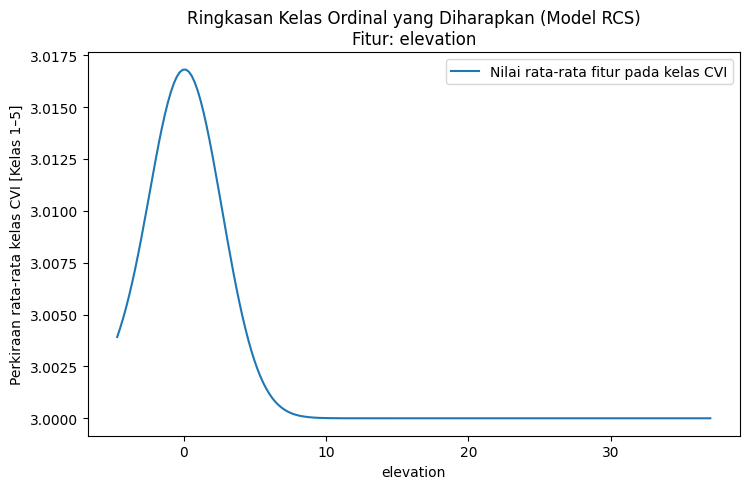

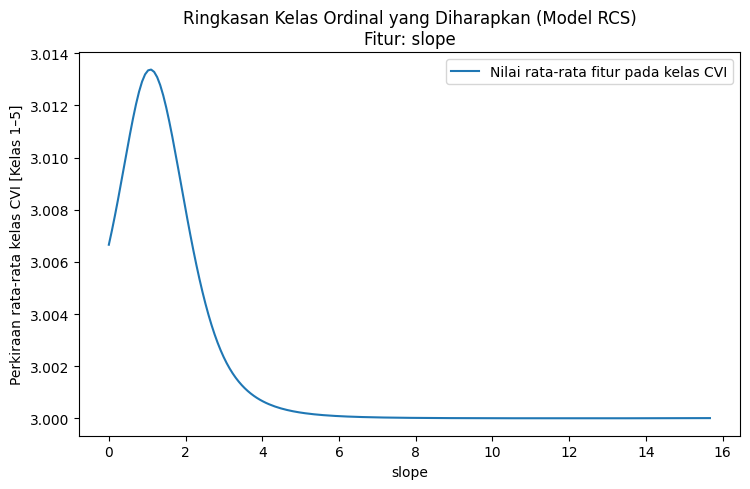

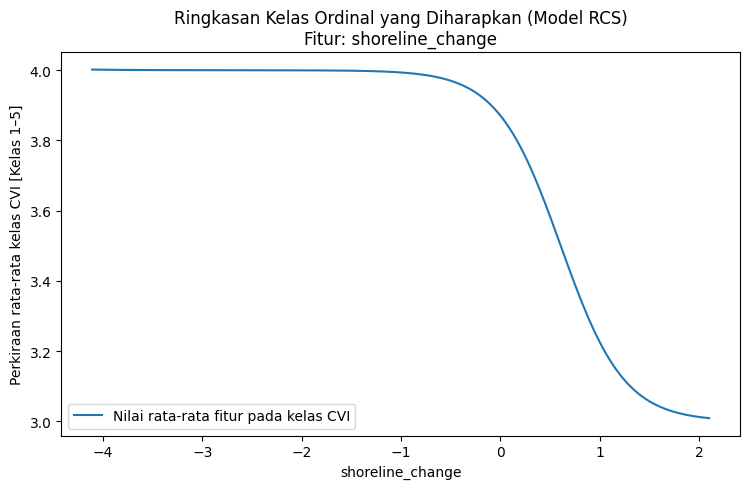

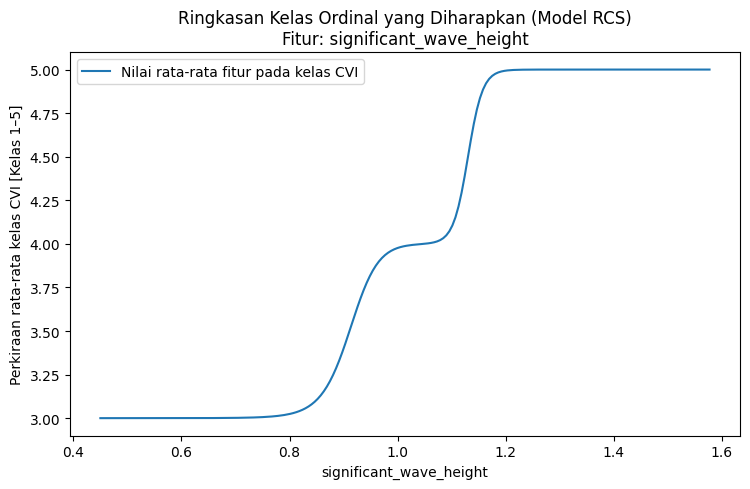

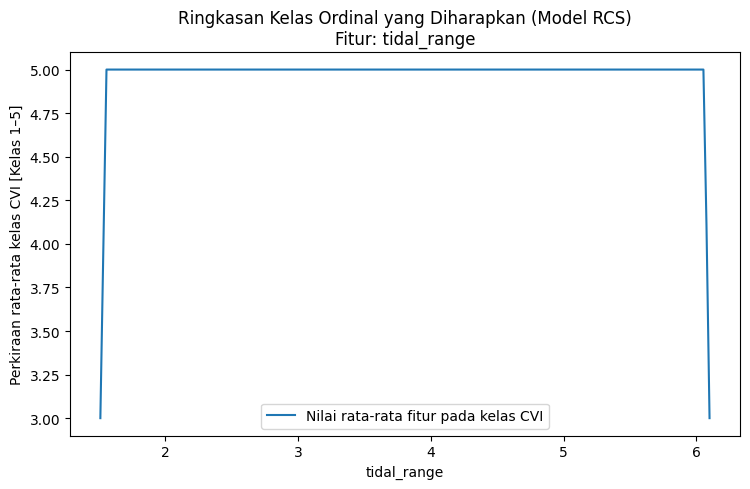

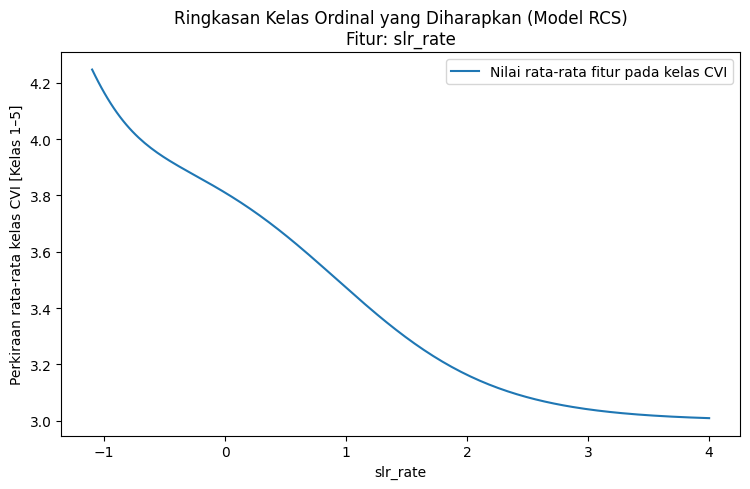

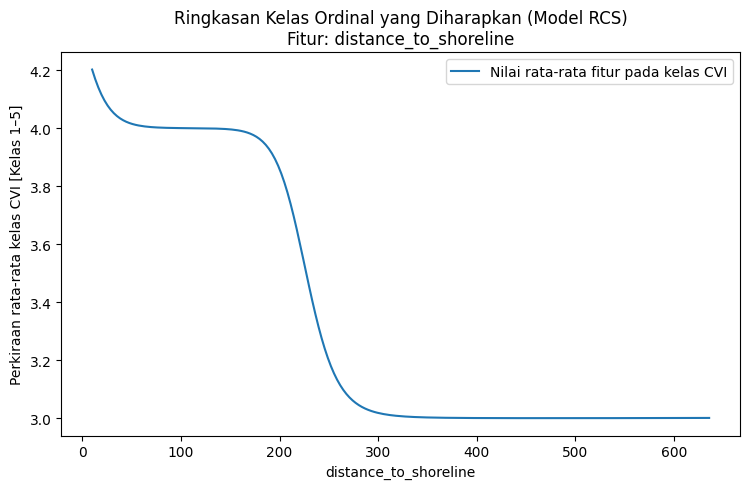

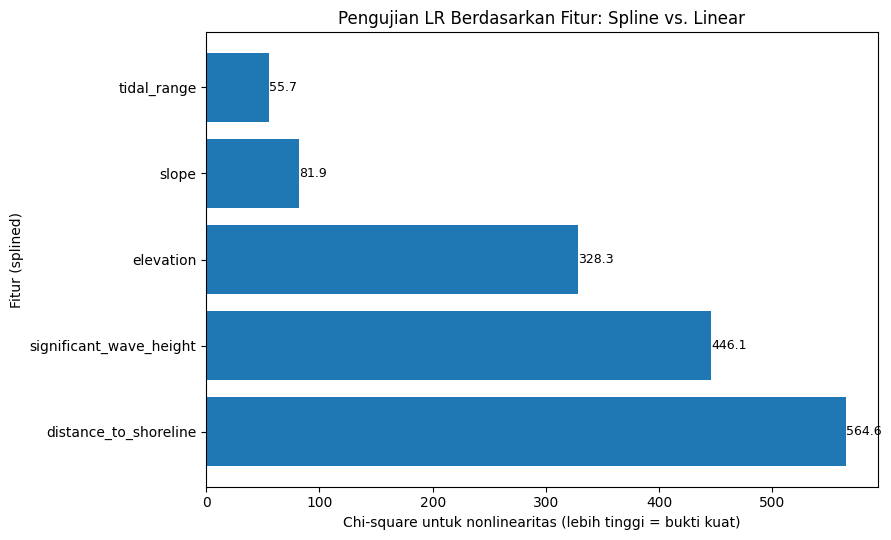


[LR TESTS FOR NONLINEARITY]
Samples used: 20000; classes: [0, 1, 2, 3, 4]
Spline vars: ['elevation', 'slope', 'significant_wave_height', 'tidal_range', 'distance_to_shoreline'] | Linear-only: ['shoreline_change', 'slr_rate']
GLOBAL: chi2=1887.71, df=15, p=0 --> NONLINEAR
Per-feature (splined) [chi2, df, p]:
  - distance_to_shoreline: 564.57, df=3, p=4.84e-122
  - significant_wave_height: 446.10, df=3, p=2.28e-96
  - elevation: 328.27, df=3, p=7.56e-71
  - slope: 81.90, df=3, p=1.2e-17
  - tidal_range: 55.65, df=3, p=4.99e-12

[All continuous features: LR nonlinearity information]
                feature             status                 reason       chi2  df_diff       p_value
              elevation            splined                        328.268458        3  7.564525e-71
                  slope            splined                         81.901021        3  1.200087e-17
       shoreline_change tested_linear_only insufficient_unique(6) 701.772891        3 8.661814e-152
significant_

In [ ]:
# --- 6. MAIN EXECUTION BLOCK ---
print("\nSTEP 6: Starting Main Execution...")

# --- Load Data, Metadata, and Preprocessors ---
try:
    print("\nLoading datasets and fitted imputer...")
    train_df_raw = pd.read_csv(TRAIN_DATA_PATH)
    test_df_raw = pd.read_csv(TEST_DATA_PATH)
    imputer = joblib.load(IMPUTER_PATH)

    with open(METADATA_PATH, 'r') as f:
        metadata = json.load(f)
    features_for_ml = metadata['features']

    train_target_col = 'class'
    test_target_col = 'class_true'

    # --- Prepare dataframes for analysis ---
    X_train_raw = train_df_raw[features_for_ml]
    y_train = train_df_raw[train_target_col]

    X_train_imputed = imputer.transform(X_train_raw)
    X_train = pd.DataFrame(X_train_imputed, columns=features_for_ml, index=X_train_raw.index)

    X_test_raw = test_df_raw[features_for_ml]
    y_test = test_df_raw[test_target_col]

    # Apply the pre-trained imputer to the raw test data
    X_test_imputed = imputer.transform(X_test_raw)
    X_test = pd.DataFrame(X_test_imputed, columns=features_for_ml, index=X_test_raw.index)

    print(f"Successfully loaded and prepared {len(X_train)} training and {len(X_test)} test samples.")
    print(f"Test data has been transformed using the saved imputer.")

except FileNotFoundError as e:
    print(f"\nFATAL ERROR: Could not find a required data or artifact file. Please check paths in Step 4.")
    print(f"Ensure 'ml_train_data_raw.csv', 'ml_test_data_raw.csv', and 'imputer.pkl' all exist.")
    print(f"Details: {e}")
    exit()

print("\nSTEP: Loading continuous CVI score for statistics module...")
y_score_train, X_train_aligned = load_cvi_continuous_for_stats(
    BASE_DIR=BASE_DIR,
    train_df_raw=train_df_raw,
    features_for_ml=features_for_ml,
    prefer_weights=("equal"),
    prefer_norm_col="cvi_score_norm",
    recompute_if_missing=True
)

# Rename 'class' column in X_train_aligned to avoid SyntaxError in formulas
if 'class' in X_train_aligned.columns:
    X_train_aligned = X_train_aligned.rename(columns={'class': 'cvi_class'})

pref_dir = os.path.join(STAT_RESULTS_DIR, "CVI_nonlinearity")

_cat = [c for c in ['geomorphology','landcover'] if c in X_train.columns]
out = cvi_linearity_nonlinearity_test_v4(
    X_train=X_train,
    y_train=y_train,
    categorical_features=_cat,
    quasi_constant_features=('slr_rate',),
    n_subsample_total=20000,
    per_class_balance=True,
    df_spline=4,
    min_unique_for_spline=10,
    random_state=1337,
    out_dir=pref_dir,
    plot_class_labels_start_at_one=True,   # show 1–5 everywhere
    class_scores=None,                     # defaults to 1..5 when the flag above is True
    make_cumulative_curves=False,
    cumulative_threshold=5,                # your “high vulnerability” cutpoint
    pms_bootstrap=False,                   # set False if you want speed
    n_boot=10,
    ci=0.95,
    make_per_class_curves=False,
    alpha_sig=0.05
)

print("\n\n--- All statistical validation tasks are complete. ---")